## Import & Install Library

In [1]:
!pip install apify-client pandas gspread google-auth

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.0/87.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 32.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
from apify_client import ApifyClient
import time
from google.colab import auth
from google.auth import default
import gspread

## Apify Token

In [3]:
# Autentikasi Google
auth.authenticate_user()
gc = gspread.authorize(default()[0])

In [4]:
APIFY_API_TOKEN = "apify_api_FutI3vmG0SgF2kR3ySULSod35eseP20qZaSB"

client = ApifyClient(APIFY_API_TOKEN)
print("\u2713 Token Apify siap digunakan.")

✓ Token Apify siap digunakan.


## Baca Spreadsheet

In [5]:
def get_sheet_data(sheet_url, gid):
    """Ambil data dari Google Sheet berdasarkan URL dan GID"""
    sheet = gc.open_by_url(sheet_url)
    worksheet = sheet.get_worksheet_by_id(gid)
    data = worksheet.get_all_records()
    df = pd.DataFrame(data)
    print(f" GID {gid}: {len(df)} baris")
    return df


df_crb_wisata = get_sheet_data("https://docs.google.com/spreadsheets/d/1lLRGQNrwMqy9WIQNILbn5fs1m6A1WKP1qC3wGhDaJtg/edit?gid=1088812862#gid=1088812862", 1088812862)
df_crb_kuliner = get_sheet_data("https://docs.google.com/spreadsheets/d/1vyip2ljDFuL8QSRgU3Fsg8mxnCKxFqnn2_E6MCLwVjA/edit?gid=1924711779#gid=1924711779", 1924711779)
df_crb_nongkrong = get_sheet_data("https://docs.google.com/spreadsheets/d/1aa0T4nF2YY4bDbQU63UQ0Jhf1NCPTT4fuTjmH3fdAyk/edit?gid=642535853#gid=642535853", 642535853)

print("\u2713 Semua sheet berhasil dibaca!")

 GID 1088812862: 30 baris
 GID 1924711779: 30 baris
 GID 642535853: 35 baris
✓ Semua sheet berhasil dibaca!


## Ekstrak URL Google Maps

In [6]:
def extract_urls(df, kategori, wilayah):
    """Ambil URL Google Maps dari kolom Link_Google_Maps"""
    if df.empty:
        print(f" {wilayah} {kategori}: DataFrame kosong")
        return []

    if 'Link_Google_Maps' not in df.columns:
        print(f" {wilayah} {kategori}: kolom 'Link_Google_Maps' tidak ditemukan")
        print(f"   Kolom yang ada: {list(df.columns)}")
        return []

    urls = df['Link_Google_Maps'].dropna().tolist()
    urls = [str(u).strip() for u in urls if 'google.com/maps' in str(u) or 'maps.app.goo.gl' in str(u)]

    print(f"\u2713 {wilayah} {kategori}: {len(urls)} URL")
    return urls

# Urls cirebon
urls_crb_wisata = extract_urls(df_crb_wisata, "Wisata", "cirebon")
urls_crb_kuliner = extract_urls(df_crb_kuliner, "Kuliner", "cirebon")
urls_crb_nongkrong = extract_urls(df_crb_nongkrong, "Nongkrong", "cirebon")
urls_cirebon = urls_crb_wisata + urls_crb_kuliner + urls_crb_nongkrong

print(f" total: {len(urls_cirebon)} tempat")

✓ cirebon Wisata: 30 URL
✓ cirebon Kuliner: 30 URL
✓ cirebon Nongkrong: 33 URL
 total: 93 tempat


## Fungsi Scraper

In [7]:
def scrape_reviews_cirebon(url_list, kategori_name, target_reviews=35):
    """
    Scrape Google Maps reviews untuk wilayah cirebon.

    Parameters:
    -----------
    url_list : list
        Daftar URL Google Maps tempat wisata di cirebon
    kategori_name : str
        Kategori tempat (contoh: 'Wisata', 'Kuliner', 'Nongkrong')
    target_reviews : int, default=35
        Jumlah ulasan yang diambil per tempat

    Returns:
    --------
    tuple : (reviews_raw_list, places_metadata_list)
        - reviews_raw_list: list of dict, berisi setiap ulasan (hanya yang memiliki teks)
        - places_metadata_list: list of dict, berisi ringkasan per tempat
    """

    # Validasi input
    if not url_list:
        print(f"[WARNING] Tidak ada URL untuk cirebon - {kategori_name}")
        return [], []

    # Estimasi biaya dengan buffer 50%
    buffer_reviews = int(target_reviews * 1.5)
    estimated_cost = (len(url_list) * buffer_reviews / 1000) * 0.60
    print(f"\n[RUN] cirebon - {kategori_name}")
    print(f"  - Jumlah tempat: {len(url_list)}")
    print(f"  - Target ulasan per tempat: {target_reviews}")
    print(f"  - Estimasi biaya: ${estimated_cost:.2f}")

    # Konversi URL ke format yang diminta Apify
    start_urls = [{"url": url} for url in url_list]

    # Konfigurasi input scraper
    actor_input = {
        "startUrls": start_urls,
        "maxReviews": buffer_reviews,
        "reviewsSort": "newest",
        "language": "id",
        "proxyConfig": {"useApifyProxy": True}
    }

    try:
        # Jalankan actor Apify
        run = client.actor("compass/google-maps-reviews-scraper").call(run_input=actor_input)

        # Ambil hasil dari dataset
        dataset = client.dataset(run["defaultDatasetId"])
        items = dataset.list_items().items

        # Inisialisasi hasil
        reviews_raw = []
        places_metadata = []
        added_places = set()

        for item in items:
            # Ambil data tempat dari item (karena 1 item = 1 ulasan)
            place_id = item.get('placeId', 'N/A')
            place_name = item.get('title', 'N/A')
            total_reviews_google = item.get('reviewsCount', 0)
            avg_rating_google = item.get('totalScore', 0.0)
            category_name_google = item.get('categoryName', 'N/A')
            categories_google = item.get('categories', [])
            latitude = item.get('location', {}).get('lat')
            longitude = item.get('location', {}).get('lng')
            scraped_at = pd.Timestamp.now().isoformat()

            # Simpan metadata tempat (hanya sekali per place_id)
            if place_id not in added_places:
                places_metadata.append({
                    'place_id': place_id,
                    'place_name': place_name,
                    'wilayah': 'cirebon',
                    'kategori': kategori_name,
                    'category_name_google': category_name_google,
                    'categories_google': str(categories_google),
                    'latitude': latitude,
                    'longitude': longitude,
                    'total_reviews_google': total_reviews_google,
                    'avg_rating_google': avg_rating_google,
                    'total_reviews_scraped': 0,
                    'scraped_at': scraped_at
                })
                added_places.add(place_id)

            # Filter: hanya simpan ulasan yang memiliki teks (bukan None dan bukan 'None')
            review_text = item.get('text')
            if review_text and review_text != 'None' and len(str(review_text).strip()) >= 15:
                reviews_raw.append({
                    'review_id': item.get('reviewId', 'N/A'),
                    'place_id': place_id,
                    'place_name': place_name,
                    'wilayah': 'cirebon',
                    'kategori': kategori_name,
                    'rating': item.get('stars'),
                    'review_text': review_text,
                    'review_date': item.get('publishedAtDate'),
                    'reviewer_name': item.get('name'),
                    'reviewer_id': item.get('reviewerId', 'N/A'),
                    'is_local_guide': item.get('isLocalGuide', False),
                    'likes_count': item.get('likesCount', 0),
                    'original_language': item.get('originalLanguage', 'N/A'),
                    'scraped_at': scraped_at
                })

        # Hitung total ulasan per tempat untuk metadata
        for place in places_metadata:
            place_id = place['place_id']
            place['total_reviews_scraped'] = len([r for r in reviews_raw if r['place_id'] == place_id])

        print(f"[SUCCESS] cirebon - {kategori_name}")
        print(f"  - Tempat discrape: {len(places_metadata)}")
        print(f"  - Total ulasan berteks: {len(reviews_raw)}")
        if len(places_metadata) > 0:
            print(f"  - Rata-rata ulasan per tempat: {len(reviews_raw)/len(places_metadata):.1f}")

        return reviews_raw, places_metadata

    except Exception as e:
        print(f"[ERROR] Scraping gagal untuk cirebon - {kategori_name}")
        print(f"  - Error: {str(e)}")
        return [], []

## Test Eksekusi

In [8]:
test_url = urls_crb_wisata[0]

reviews_test, metadata_test = scrape_reviews_cirebon(
    url_list=[test_url],
    kategori_name="test",
    target_reviews=5
)

if reviews_test:
    print("berhasil")
    print(f"jumlah ulasan: {len(reviews_test)}")
    print(f"nama tempat: {metadata_test[0]['place_name']}")
    print(f"rating: {reviews_test[0]['rating']}")
    print(f"ulasan: {reviews_test[0]['review_text']}")
else:
    print("gagal")


[RUN] cirebon - test
  - Jumlah tempat: 1
  - Target ulasan per tempat: 5
  - Estimasi biaya: $0.00


[apify.Google-Maps-Reviews-Scraper runId:chAyFnZDXkQFU6YZ7] -> Status: RUNNING, Message: 
[apify.Google-Maps-Reviews-Scraper runId:chAyFnZDXkQFU6YZ7] -> 2026-05-05T05:35:30.272Z ACTOR: Pulling container image of build c3go3Yxyd9bJa2vOZ from registry.
[apify.Google-Maps-Reviews-Scraper runId:chAyFnZDXkQFU6YZ7] -> 2026-05-05T05:35:30.274Z ACTOR: Creating container.
[apify.Google-Maps-Reviews-Scraper runId:chAyFnZDXkQFU6YZ7] -> 2026-05-05T05:35:30.361Z ACTOR: Starting container.
[apify.Google-Maps-Reviews-Scraper runId:chAyFnZDXkQFU6YZ7] -> 2026-05-05T05:35:30.363Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.Google-Maps-Reviews-Scraper runId:chAyFnZDXkQFU6YZ7] -> 2026-05-05T05:35:31.476Z INFO  System info {"apifyVersion":"3.5.3","apifyClientVersion":"2.19.0","crawleeVersion":"3.16.0","osType":"Linux","nodeVersion":"v24.15.0"}
[apify.Google-Maps-Reviews-Scraper runId:chAyFnZDXkQFU6YZ7] -> 2026-05-05T05:35:31.871Z INFO  [BG ENQUEUE] Finished enqueueing
[apify.Google-

[SUCCESS] cirebon - test
  - Tempat discrape: 1
  - Total ulasan berteks: 3
  - Rata-rata ulasan per tempat: 3.0
berhasil
jumlah ulasan: 3
nama tempat: Kopi Manao
rating: 5
ulasan: kopi susu kita nya bikin terngiang ngiang, enak bgt, barista nya so far ramah, udah jadi rumah kedua, kalo bingung mau kemana, pasti selalu opsi utama nya kesini hehehe


In [9]:
print("Daftar Ulasan Test : ")
print("-" * 30)

for i, review in enumerate(reviews_test, 1):
    print(f"\n[i] Ulasan Ke-{i}")
    print(f"    rating    : {review['rating']} bintang")
    print(f"    reviewer  : {review['reviewer_name']}")
    print(f"    tanggal   : {review['review_date'][:10]}")

    teks = review['review_text']
    if teks and teks != 'None':
        print(f"    teks      : {teks[:200]}")
        if len(teks) > 200:
            print(f"                {teks[200:]}")
    else:
        print(f"    teks      : [tidak ada teks ulasan]")

    print("-" * 30)

Daftar Ulasan Test : 
------------------------------

[i] Ulasan Ke-1
    rating    : 5 bintang
    reviewer  : Ilham Jaya
    tanggal   : 2026-04-15
    teks      : kopi susu kita nya bikin terngiang ngiang, enak bgt, barista nya so far ramah, udah jadi rumah kedua, kalo bingung mau kemana, pasti selalu opsi utama nya kesini hehehe
------------------------------

[i] Ulasan Ke-2
    rating    : 5 bintang
    reviewer  : Fitri Yuliati
    tanggal   : 2026-04-13
    teks      : Mirip2 lah tastenya sama kopi tuku dan kopi makmur jaya 😁
------------------------------

[i] Ulasan Ke-3
    rating    : 5 bintang
    reviewer  : Rizki Setyo
    tanggal   : 2026-03-28
    teks      : Best kopsu kita
------------------------------


## Eksekusi

In [10]:
print("\u2713 Memulai Scraping...")

# Scraping Wisata cirebon
reviews_wisata, metadata_wisata = scrape_reviews_cirebon(
    url_list=urls_crb_wisata,
    kategori_name="Wisata",
    target_reviews=35
)

# Scraping Kuliner cirebon
reviews_kuliner, metadata_kuliner = scrape_reviews_cirebon(
    url_list=urls_crb_kuliner,
    kategori_name="Kuliner",
    target_reviews=35
)

# Scraping Nongkrong cirebon
reviews_nongkrong, metadata_nongkrong = scrape_reviews_cirebon(
    url_list=urls_crb_nongkrong,
    kategori_name="Nongkrong",
    target_reviews=35
)

print("\u2713 Scraping Selesai!")
print(f"Wisata: {len(reviews_wisata)} ulasan, {len(metadata_wisata)} tempat")
print(f"Kuliner: {len(reviews_kuliner)} ulasan, {len(metadata_kuliner)} tempat")
print(f"Nongkrong: {len(reviews_nongkrong)} ulasan, {len(metadata_nongkrong)} tempat")

✓ Memulai Scraping...

[RUN] cirebon - Wisata
  - Jumlah tempat: 30
  - Target ulasan per tempat: 35
  - Estimasi biaya: $0.94


[apify.Google-Maps-Reviews-Scraper runId:PfmaiizxBZoqLAWmJ] -> Status: RUNNING, Message: 
[apify.Google-Maps-Reviews-Scraper runId:PfmaiizxBZoqLAWmJ] -> 2026-05-05T05:35:47.070Z ACTOR: Pulling container image of build c3go3Yxyd9bJa2vOZ from registry.
[apify.Google-Maps-Reviews-Scraper runId:PfmaiizxBZoqLAWmJ] -> 2026-05-05T05:35:47.072Z ACTOR: Creating container.
[apify.Google-Maps-Reviews-Scraper runId:PfmaiizxBZoqLAWmJ] -> 2026-05-05T05:35:47.123Z ACTOR: Starting container.
[apify.Google-Maps-Reviews-Scraper runId:PfmaiizxBZoqLAWmJ] -> 2026-05-05T05:35:47.125Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.Google-Maps-Reviews-Scraper runId:PfmaiizxBZoqLAWmJ] -> 2026-05-05T05:35:48.354Z INFO  System info {"apifyVersion":"3.5.3","apifyClientVersion":"2.19.0","crawleeVersion":"3.16.0","osType":"Linux","nodeVersion":"v24.15.0"}
[apify.Google-Maps-Reviews-Scraper runId:PfmaiizxBZoqLAWmJ] -> 2026-05-05T05:35:48.786Z INFO  [BG ENQUEUE] Finished enqueueing
[apify.Google-

[SUCCESS] cirebon - Wisata
  - Tempat discrape: 30
  - Total ulasan berteks: 878
  - Rata-rata ulasan per tempat: 29.3

[RUN] cirebon - Kuliner
  - Jumlah tempat: 30
  - Target ulasan per tempat: 35
  - Estimasi biaya: $0.94


[apify.Google-Maps-Reviews-Scraper runId:GDIwM8jy9Bop1Kwyd] -> Status: RUNNING, Message: 
[apify.Google-Maps-Reviews-Scraper runId:GDIwM8jy9Bop1Kwyd] -> 2026-05-05T05:37:00.264Z ACTOR: Pulling container image of build c3go3Yxyd9bJa2vOZ from registry.
[apify.Google-Maps-Reviews-Scraper runId:GDIwM8jy9Bop1Kwyd] -> 2026-05-05T05:37:00.266Z ACTOR: Creating container.
[apify.Google-Maps-Reviews-Scraper runId:GDIwM8jy9Bop1Kwyd] -> 2026-05-05T05:37:00.387Z ACTOR: Starting container.
[apify.Google-Maps-Reviews-Scraper runId:GDIwM8jy9Bop1Kwyd] -> 2026-05-05T05:37:00.388Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.Google-Maps-Reviews-Scraper runId:GDIwM8jy9Bop1Kwyd] -> 2026-05-05T05:37:01.488Z INFO  System info {"apifyVersion":"3.5.3","apifyClientVersion":"2.19.0","crawleeVersion":"3.16.0","osType":"Linux","nodeVersion":"v24.15.0"}
[apify.Google-Maps-Reviews-Scraper runId:GDIwM8jy9Bop1Kwyd] -> 2026-05-05T05:37:01.893Z INFO  [BG ENQUEUE] Finished enqueueing
[apify.Google-

[SUCCESS] cirebon - Kuliner
  - Tempat discrape: 28
  - Total ulasan berteks: 720
  - Rata-rata ulasan per tempat: 25.7

[RUN] cirebon - Nongkrong
  - Jumlah tempat: 33
  - Target ulasan per tempat: 35
  - Estimasi biaya: $1.03


[apify.Google-Maps-Reviews-Scraper runId:tdl5rdi0zte9izTAp] -> Status: RUNNING, Message: 
[apify.Google-Maps-Reviews-Scraper runId:tdl5rdi0zte9izTAp] -> 2026-05-05T05:38:10.791Z ACTOR: Pulling container image of build c3go3Yxyd9bJa2vOZ from registry.
[apify.Google-Maps-Reviews-Scraper runId:tdl5rdi0zte9izTAp] -> 2026-05-05T05:38:10.793Z ACTOR: Creating container.
[apify.Google-Maps-Reviews-Scraper runId:tdl5rdi0zte9izTAp] -> 2026-05-05T05:38:10.853Z ACTOR: Starting container.
[apify.Google-Maps-Reviews-Scraper runId:tdl5rdi0zte9izTAp] -> 2026-05-05T05:38:10.855Z ACTOR: Running under "LIMITED_PERMISSIONS" permission level.
[apify.Google-Maps-Reviews-Scraper runId:tdl5rdi0zte9izTAp] -> 2026-05-05T05:38:12.078Z INFO  System info {"apifyVersion":"3.5.3","apifyClientVersion":"2.19.0","crawleeVersion":"3.16.0","osType":"Linux","nodeVersion":"v24.15.0"}
[apify.Google-Maps-Reviews-Scraper runId:tdl5rdi0zte9izTAp] -> 2026-05-05T05:38:12.565Z INFO  [BG ENQUEUE] Finished enqueueing
[apify.Google-

[SUCCESS] cirebon - Nongkrong
  - Tempat discrape: 31
  - Total ulasan berteks: 611
  - Rata-rata ulasan per tempat: 19.7
✓ Scraping Selesai!
Wisata: 878 ulasan, 30 tempat
Kuliner: 720 ulasan, 28 tempat
Nongkrong: 611 ulasan, 31 tempat


## Simpan Hasil

In [11]:
print("\u2713 Menyimpan hasil scraping...")

# Wisata
df_reviews_wisata = pd.DataFrame(reviews_wisata)
df_metadata_wisata = pd.DataFrame(metadata_wisata)
df_reviews_wisata.to_csv('cirebon_wisata_reviews.csv', index=False, encoding='utf-8-sig')
df_metadata_wisata.to_csv('cirebon_wisata_metadata.csv', index=False, encoding='utf-8-sig')

# Kuliner
df_reviews_kuliner = pd.DataFrame(reviews_kuliner)
df_metadata_kuliner = pd.DataFrame(metadata_kuliner)
df_reviews_kuliner.to_csv('cirebon_kuliner_reviews.csv', index=False, encoding='utf-8-sig')
df_metadata_kuliner.to_csv('cirebon_kuliner_metadata.csv', index=False, encoding='utf-8-sig')

# Nongkrong
df_reviews_nongkrong = pd.DataFrame(reviews_nongkrong)
df_metadata_nongkrong = pd.DataFrame(metadata_nongkrong)
df_reviews_nongkrong.to_csv('cirebon_nongkrong_reviews.csv', index=False, encoding='utf-8-sig')
df_metadata_nongkrong.to_csv('cirebon_nongkrong_metadata.csv', index=False, encoding='utf-8-sig')

print("\u2713 File tersimpan:")
print("  - cirebon_wisata_reviews.csv")
print("  - cirebon_wisata_metadata.csv")
print("  - cirebon_kuliner_reviews.csv")
print("  - cirebon_kuliner_metadata.csv")
print("  - cirebon_nongkrong_reviews.csv")
print("  - cirebon_nongkrong_metadata.csv")

✓ Menyimpan hasil scraping...
✓ File tersimpan:
  - cirebon_wisata_reviews.csv
  - cirebon_wisata_metadata.csv
  - cirebon_kuliner_reviews.csv
  - cirebon_kuliner_metadata.csv
  - cirebon_nongkrong_reviews.csv
  - cirebon_nongkrong_metadata.csv


## Load Data

In [12]:
import pandas as pd

print("Membaca semua file csv")
print()

# Baca semua file
df_wisata_reviews = pd.read_csv('cirebon_wisata_reviews.csv')
df_wisata_metadata = pd.read_csv('cirebon_wisata_metadata.csv')

df_kuliner_reviews = pd.read_csv('cirebon_kuliner_reviews.csv')
df_kuliner_metadata = pd.read_csv('cirebon_kuliner_metadata.csv')

df_nongkrong_reviews = pd.read_csv('cirebon_nongkrong_reviews.csv')
df_nongkrong_metadata = pd.read_csv('cirebon_nongkrong_metadata.csv')

print("File berhasil dibaca")
print()

print("Data ulasan wisata")
print("-" * 35)
print(f"Jumlah ulasan: {len(df_wisata_reviews)}")
print(f"Jumlah tempat unik: {df_wisata_reviews['place_name'].nunique()}")
print(f"Kolom: {list(df_wisata_reviews.columns)}")
print()
print("5 ulasan pertama:")
print(df_wisata_reviews[['place_name', 'rating', 'review_text', 'review_date']].head())
print()

print("Data ulasan kuliner")
print("-" * 35)
print(f"Jumlah ulasan: {len(df_kuliner_reviews)}")
print(f"Jumlah tempat unik: {df_kuliner_reviews['place_name'].nunique()}")
print()
print("5 ulasan pertama:")
print(df_kuliner_reviews[['place_name', 'rating', 'review_text', 'review_date']].head())
print()

print("Data ulasan nongkrong")
print("-" * 35)
print(f"Jumlah ulasan: {len(df_nongkrong_reviews)}")
print(f"Jumlah tempat unik: {df_nongkrong_reviews['place_name'].nunique()}")
print()
print("5 ulasan pertama:")
print(df_nongkrong_reviews[['place_name', 'rating', 'review_text', 'review_date']].head())

Membaca semua file csv

File berhasil dibaca

Data ulasan wisata
-----------------------------------
Jumlah ulasan: 878
Jumlah tempat unik: 30
Kolom: ['review_id', 'place_id', 'place_name', 'wilayah', 'kategori', 'rating', 'review_text', 'review_date', 'reviewer_name', 'reviewer_id', 'is_local_guide', 'likes_count', 'original_language', 'scraped_at']

5 ulasan pertama:
                       place_name  rating  \
0  KEMARE.ID - Latte & Patisserie       5   
1  KEMARE.ID - Latte & Patisserie       5   
2  KEMARE.ID - Latte & Patisserie       5   
3  KEMARE.ID - Latte & Patisserie       5   
4  KEMARE.ID - Latte & Patisserie       5   

                                     review_text               review_date  
0                            Kwetiaunya mantap 🥰  2026-05-05T03:33:59.859Z  
1   Tempatnya nyaman dan makanannya enak, best 🥰  2026-05-05T02:57:29.635Z  
2  Syahdu banget ini tempatnya, menunya variatif  2026-04-29T11:39:24.837Z  
3       cozy tempatnya, enak makanan dan kopinya 

## **Visualisasi statistik ulasan**

/tmp/ipykernel_12614/769381928.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(data_box, labels=['Wisata', 'Kuliner', 'Nongkrong'], patch_artist=True)


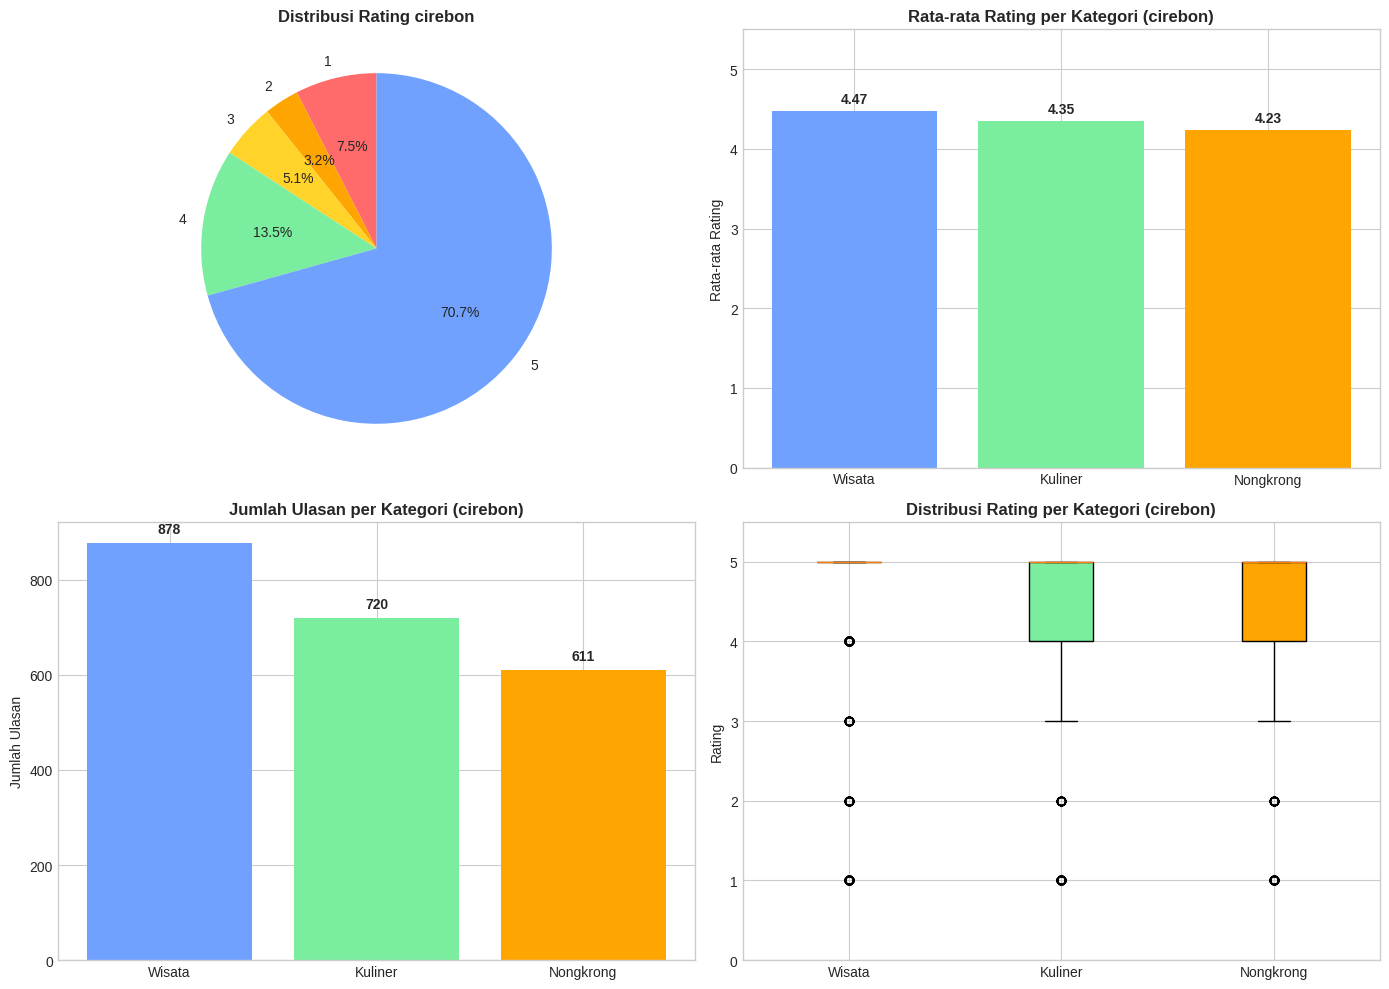

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

all_reviews = pd.concat([
    df_wisata_reviews,
    df_kuliner_reviews,
    df_nongkrong_reviews
], ignore_index=True)

# setting style
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(14, 10))

# 1. distribusi rating (pie chart)
ax1 = fig.add_subplot(2, 2, 1)
rating_counts = all_reviews['rating'].value_counts().sort_index()
colors = ['#ff6b6b', '#ffa502', '#ffd32a', '#7bed9f', '#70a1ff']
wedges, texts, autotexts = ax1.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%',
                                    colors=colors[:len(rating_counts)], startangle=90)
ax1.set_title('Distribusi Rating cirebon', fontsize=12, fontweight='bold')

# 2. rata-rata rating per kategori (bar chart)
ax2 = fig.add_subplot(2, 2, 2)
kategori_rating = {
    'Wisata': df_wisata_reviews['rating'].mean(),
    'Kuliner': df_kuliner_reviews['rating'].mean(),
    'Nongkrong': df_nongkrong_reviews['rating'].mean()
}
bars = ax2.bar(kategori_rating.keys(), kategori_rating.values(), color=['#70a1ff', '#7bed9f', '#ffa502'])
ax2.set_ylim(0, 5.5)
ax2.set_ylabel('Rata-rata Rating')
ax2.set_title('Rata-rata Rating per Kategori (cirebon)', fontsize=12, fontweight='bold')
for bar, val in zip(bars, kategori_rating.values()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}', ha='center', fontweight='bold')

# 3. jumlah ulasan per kategori (bar chart)
ax3 = fig.add_subplot(2, 2, 3)
kategori_jumlah = {
    'Wisata': len(df_wisata_reviews),
    'Kuliner': len(df_kuliner_reviews),
    'Nongkrong': len(df_nongkrong_reviews)
}
bars = ax3.bar(kategori_jumlah.keys(), kategori_jumlah.values(), color=['#70a1ff', '#7bed9f', '#ffa502'])
ax3.set_ylabel('Jumlah Ulasan')
ax3.set_title('Jumlah Ulasan per Kategori (cirebon)', fontsize=12, fontweight='bold')
for bar, val in zip(bars, kategori_jumlah.values()):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(val), ha='center', fontweight='bold')

# 4. distribusi rating per kategori (boxplot)
ax4 = fig.add_subplot(2, 2, 4)
data_box = [df_wisata_reviews['rating'], df_kuliner_reviews['rating'], df_nongkrong_reviews['rating']]
bp = ax4.boxplot(data_box, labels=['Wisata', 'Kuliner', 'Nongkrong'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#70a1ff', '#7bed9f', '#ffa502']):
    patch.set_facecolor(color)
ax4.set_ylabel('Rating')
ax4.set_title('Distribusi Rating per Kategori (cirebon)', fontsize=12, fontweight='bold')
ax4.set_ylim(0, 5.5)

plt.tight_layout()
plt.show()

## **Visualisasi top tempat dan rating tertinggi**

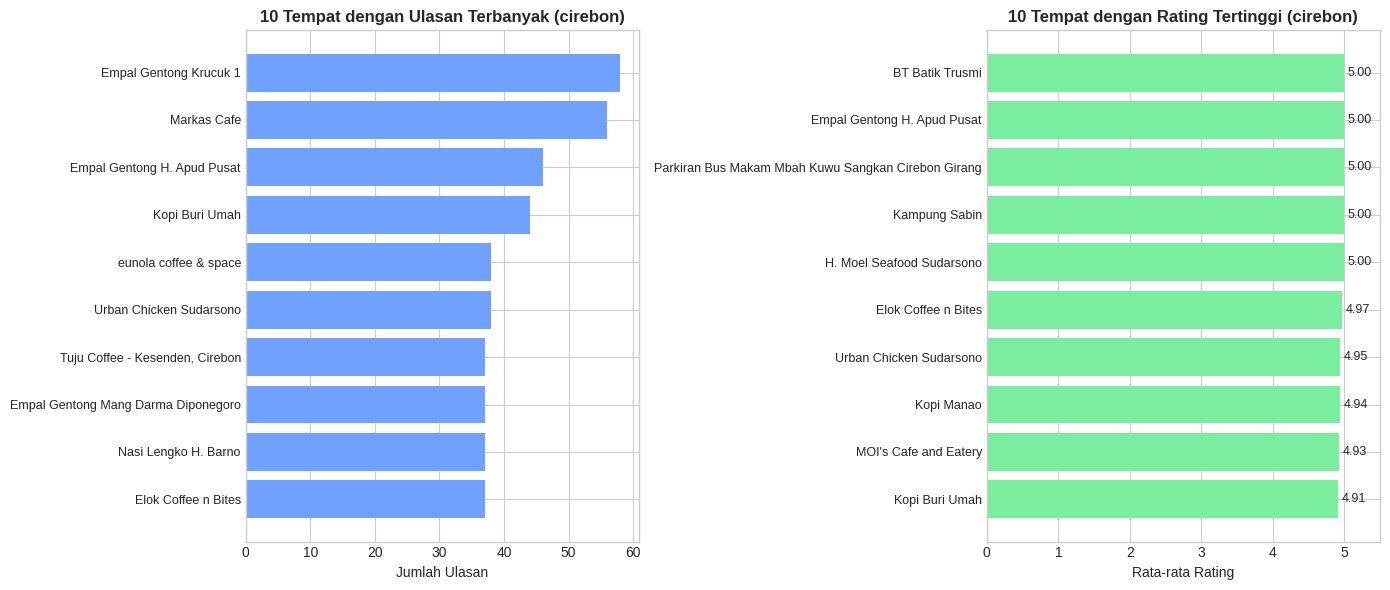

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. 10 tempat dengan ulasan terbanyak
top_places = all_reviews['place_name'].value_counts().head(10)
axes[0].barh(range(len(top_places)), top_places.values, color='#70a1ff')
axes[0].set_yticks(range(len(top_places)))
axes[0].set_yticklabels(top_places.index, fontsize=9)
axes[0].set_xlabel('Jumlah Ulasan')
axes[0].set_title('10 Tempat dengan Ulasan Terbanyak (cirebon)', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# 2. rata-rata rating per tempat (top 10)
avg_rating_per_place = all_reviews.groupby('place_name')['rating'].mean().sort_values(ascending=False).head(10)
bars = axes[1].barh(range(len(avg_rating_per_place)), avg_rating_per_place.values, color='#7bed9f')
axes[1].set_yticks(range(len(avg_rating_per_place)))
axes[1].set_yticklabels(avg_rating_per_place.index, fontsize=9)
axes[1].set_xlabel('Rata-rata Rating')
axes[1].set_title('10 Tempat dengan Rating Tertinggi (cirebon)', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 5.5)
axes[1].invert_yaxis()

# tambahkan nilai di ujung bar
for bar, val in zip(bars, avg_rating_per_place.values):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()